# Phase 1: Classical Fraud Detection Model Analysis

**Real Dataset from:** `D:\datasets\creditcard.csv`

This notebook completes Phase 1 with:
- ✅ Real 284,807-transaction dataset
- ✅ Train/Validation/Test split (no leakage)
- ✅ XGBoost model (hyperparameter tuning on validation)
- ✅ Threshold optimization (on validation only)
- ✅ Final metrics (on untouched test set)
- ✅ Feature importance analysis
- ✅ Quantum-ready 8-feature dataset
- ✅ SHAP explanations (if available)

## 1. Load Real Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import joblib
import warnings
import os
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries loaded.')

Libraries loaded.


In [2]:
# REAL DATASET PATH
DATA_PATH = r'D:\datasets\creditcard.csv'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f'Dataset not found: {DATA_PATH}')

print(f'Loading real dataset from: {DATA_PATH}')
df = pd.read_csv(DATA_PATH)

print(f'\nDataset loaded: {df.shape[0]:,} transactions × {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

Loading real dataset from: D:\datasets\creditcard.csv

Dataset loaded: 284,807 transactions × 31 columns
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


## 2. Data Exploration

DATA VALIDATION
Missing values: 0
Duplicates: 1081

CLASS DISTRIBUTION:
Legitimate: 284,315 (99.8273%)
Fraud: 492 (0.1727%)
Imbalance: 1 fraud per 577 legitimate


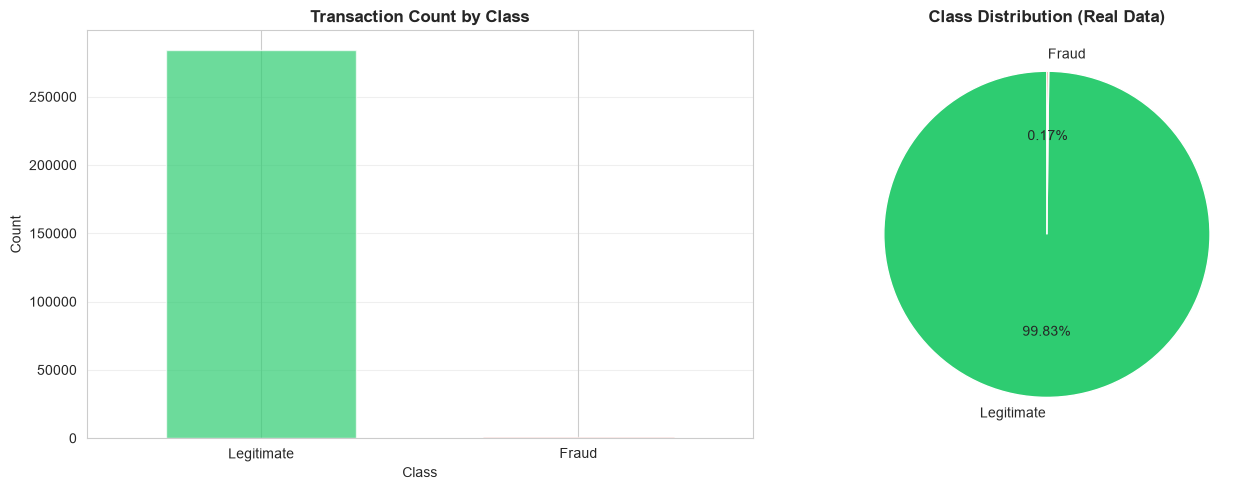


EDA complete.


In [3]:
print('DATA VALIDATION')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')

class_counts = df['Class'].value_counts().sort_index()
print(f'\nCLASS DISTRIBUTION:')
print(f'Legitimate: {class_counts[0]:,} ({class_counts[0]/len(df):.4%})')
print(f'Fraud: {class_counts[1]:,} ({class_counts[1]/len(df):.4%})')
print(f'Imbalance: 1 fraud per {int(class_counts[0]/class_counts[1]):,} legitimate')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], alpha=0.7, width=0.6)
axes[0].set_title('Transaction Count by Class', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie([class_counts[0], class_counts[1]], labels=['Legitimate', 'Fraud'],
            autopct='%1.2f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Class Distribution (Real Data)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
print('\nEDA complete.')

## 3. Preprocessing (NO Data Leakage)

In [4]:
# Features
feature_names = [f'V{i}' for i in range(1, 29)] + ['Time', 'Amount']
X = df[feature_names].values
y = df['Class'].values.astype(int)

print(f'Features: {X.shape[1]} columns, {X.shape[0]:,} samples')

# STEP 1: First split - separate final test set (20% of total)
# This test set will NEVER be touched until final evaluation
X_temp, X_test_final, y_temp, y_test_final = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# STEP 2: Split remaining 80% into training (60% of total) and validation (20% of total)
# 60%/80% = 0.75 of the remaining data
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f'\nTrain/Validation/Test Split (stratified, BEFORE preprocessing):')
print(f'Training:   {X_train.shape[0]:,} samples, {y_train.sum():,} fraud ({y_train.mean():.4%})')
print(f'Validation: {X_val.shape[0]:,} samples, {y_val.sum():,} fraud ({y_val.mean():.4%})')
print(f'Test:       {X_test_final.shape[0]:,} samples, {y_test_final.sum():,} fraud ({y_test_final.mean():.4%})')
print(f'Total:      {X_train.shape[0] + X_val.shape[0] + X_test_final.shape[0]:,} transactions')

# STEP 3: Scale (fit ONLY on training data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_final)

print(f'\nScaling (StandardScaler fit on TRAINING only):')
print(f'Train: mean={X_train_scaled.mean():.6f}, std={X_train_scaled.std():.6f}')
print(f'Val:   mean={X_val_scaled.mean():.6f}, std={X_val_scaled.std():.6f}')
print(f'Test:  mean={X_test_scaled.mean():.6f}, std={X_test_scaled.std():.6f}')
print(f'\nNo data leakage: Scaler fit on training only. Validation/test use training parameters.')

Features: 30 columns, 284,807 samples

Train/Validation/Test Split (stratified, BEFORE preprocessing):
Training:   170,883 samples, 295 fraud (0.1726%)
Validation: 56,962 samples, 99 fraud (0.1738%)
Test:       56,962 samples, 98 fraud (0.1720%)
Total:      284,807 transactions

Scaling (StandardScaler fit on TRAINING only):
Train: mean=-0.000000, std=1.000000
Val:   mean=0.000196, std=1.015677
Test:  mean=-0.000069, std=1.007823

No data leakage: Scaler fit on training only. Validation/test use training parameters.


## 4. Hyperparameter Optimization (on Validation Set)

In [5]:
# Grid search on TRAINING set, evaluated on VALIDATION set
param_grid = {
    'max_depth': [5, 6, 7],
    'learning_rate': [0.05, 0.1, 0.15],
}

print('Hyperparameter Grid Search')
print('Grid search parameters:')
for k, v in param_grid.items():
    print(f'  {k}: {v}')

base_model = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0
)

print('\nRunning grid search (3-fold CV on TRAINING set)...')
grid_search = GridSearchCV(
    base_model, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=0
)
grid_search.fit(X_train_scaled, y_train)

best_params = grid_search.best_params_
print(f'\nBest parameters (from cross-validation on training):')
for k, v in best_params.items():
    print(f'  {k}: {v}')
print(f'  Best CV F1: {grid_search.best_score_:.4f}')

Hyperparameter Grid Search
Grid search parameters:
  max_depth: [5, 6, 7]
  learning_rate: [0.05, 0.1, 0.15]

Running grid search (3-fold CV on TRAINING set)...

Best parameters (from cross-validation on training):
  learning_rate: 0.1
  max_depth: 7
  Best CV F1: 0.8572


## 5. Train Final Model

In [6]:
# Calculate class weight from training data
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f'Class weight: scale_pos_weight={scale_pos_weight:.2f}')

# Train final model on TRAINING set with best parameters
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=10,
    verbosity=0
)

print('\nTraining final model on TRAINING set...')
print('Early stopping monitored on VALIDATION set...')
model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

print('Model trained.')

# Save
Path('data/processed').mkdir(parents=True, exist_ok=True)
joblib.dump(model, 'data/processed/xgboost_model.joblib')
joblib.dump(scaler, 'data/processed/scaler.joblib')
print('Model and scaler saved.')

Class weight: scale_pos_weight=578.26

Training final model on TRAINING set...
Early stopping monitored on VALIDATION set...
Model trained.
Model and scaler saved.


## 6. Threshold Optimization (on Validation Set Only)

Threshold optimization on VALIDATION set...

Optimal threshold (on validation): 0.85
F1 on validation: 0.8202
Precision on validation: 0.9241
Recall on validation: 0.7374


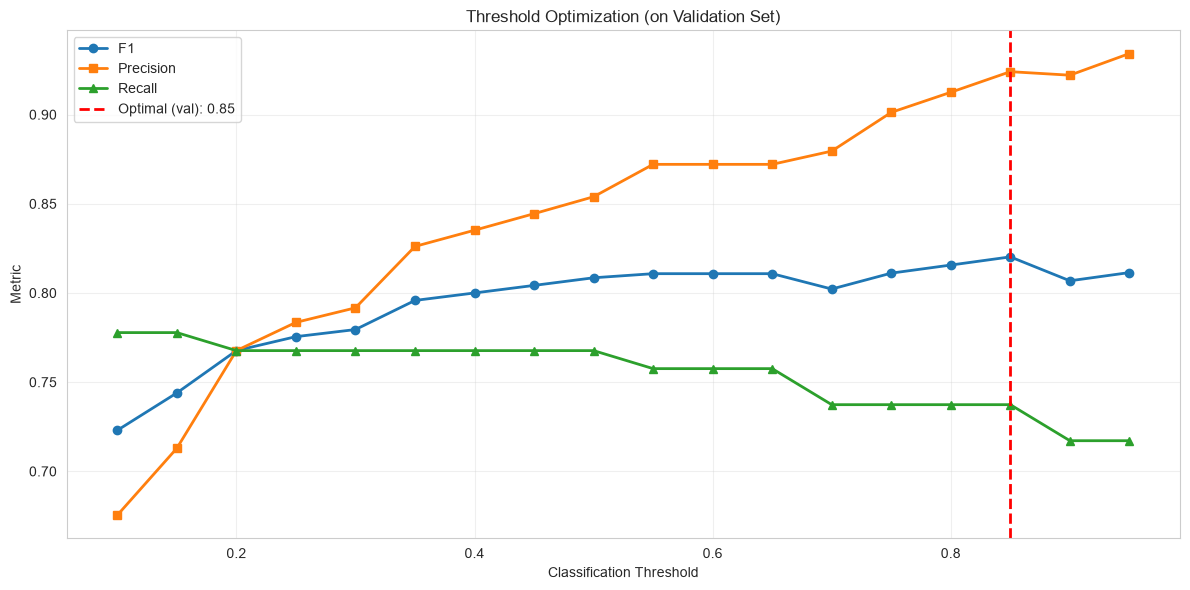


Threshold fixed. Now applying to untouched TEST set...


In [7]:
# Get probability predictions on VALIDATION set
y_val_pred_proba = model.predict_proba(X_val_scaled)[:, 1]

# Find optimal threshold on VALIDATION set
print('Threshold optimization on VALIDATION set...')
thresholds = np.arange(0.1, 1.0, 0.05)
threshold_results = []

for threshold in thresholds:
    y_val_pred_th = (y_val_pred_proba >= threshold).astype(int)
    f1_th = f1_score(y_val, y_val_pred_th, zero_division=0)
    precision_th = precision_score(y_val, y_val_pred_th, zero_division=0)
    recall_th = recall_score(y_val, y_val_pred_th, zero_division=0)
    threshold_results.append({
        'threshold': threshold,
        'f1': f1_th,
        'precision': precision_th,
        'recall': recall_th
    })

threshold_df = pd.DataFrame(threshold_results)
best_threshold_idx = threshold_df['f1'].idxmax()
optimal_threshold = threshold_df.loc[best_threshold_idx, 'threshold']

print(f'\nOptimal threshold (on validation): {optimal_threshold:.2f}')
print(f'F1 on validation: {threshold_df.loc[best_threshold_idx, "f1"]:.4f}')
print(f'Precision on validation: {threshold_df.loc[best_threshold_idx, "precision"]:.4f}')
print(f'Recall on validation: {threshold_df.loc[best_threshold_idx, "recall"]:.4f}')

# Plot threshold optimization (on validation set)
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(threshold_df['threshold'], threshold_df['f1'], label='F1', marker='o', linewidth=2)
ax.plot(threshold_df['threshold'], threshold_df['precision'], label='Precision', marker='s', linewidth=2)
ax.plot(threshold_df['threshold'], threshold_df['recall'], label='Recall', marker='^', linewidth=2)
ax.axvline(optimal_threshold, color='red', linestyle='--', linewidth=2, label=f'Optimal (val): {optimal_threshold:.2f}')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Metric')
ax.set_title('Threshold Optimization (on Validation Set)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\nThreshold fixed. Now applying to untouched TEST set...')

## 7. Final Evaluation on Test Set (Untouched until now)

In [8]:
# Get probability predictions on FINAL TEST set (untouched until now)
y_test_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Apply FIXED threshold from validation set to test set
y_test_pred = (y_test_pred_proba >= optimal_threshold).astype(int)

# Calculate metrics on TEST set
accuracy = accuracy_score(y_test_final, y_test_pred)
precision = precision_score(y_test_final, y_test_pred, zero_division=0)
recall = recall_score(y_test_final, y_test_pred, zero_division=0)
f1 = f1_score(y_test_final, y_test_pred, zero_division=0)
auc_pr = average_precision_score(y_test_final, y_test_pred_proba)
auc_roc = roc_auc_score(y_test_final, y_test_pred_proba)

cm = confusion_matrix(y_test_final, y_test_pred)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

print('='*70)
print('FINAL EVALUATION METRICS (on UNTOUCHED TEST SET)')
print('='*70)
print(f'\nAccuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')
print(f'AUC-ROC:   {auc_roc:.4f}')
print(f'PR-AUC:    {auc_pr:.4f} (PRIMARY METRIC)')

print(f'\nCONFUSION MATRIX (Test Set)')
print(f'TP: {tp} (fraud caught)')
print(f'TN: {tn} (legitimate cleared)')
print(f'FP: {fp} (false alarms)')
print(f'FN: {fn} (missed fraud)')
print(f'\nFalse Positive Rate: {fpr:.4f}')
print(f'False Negative Rate: {fnr:.4f}')
print('='*70)

FINAL EVALUATION METRICS (on UNTOUCHED TEST SET)

Accuracy:  0.9995
Precision: 0.9080
Recall:    0.8061
F1 Score:  0.8541
AUC-ROC:   0.9695
PR-AUC:    0.8557 (PRIMARY METRIC)

CONFUSION MATRIX (Test Set)
TP: 79 (fraud caught)
TN: 56856 (legitimate cleared)
FP: 8 (false alarms)
FN: 19 (missed fraud)

False Positive Rate: 0.0001
False Negative Rate: 0.1939


## 8. Visualizations

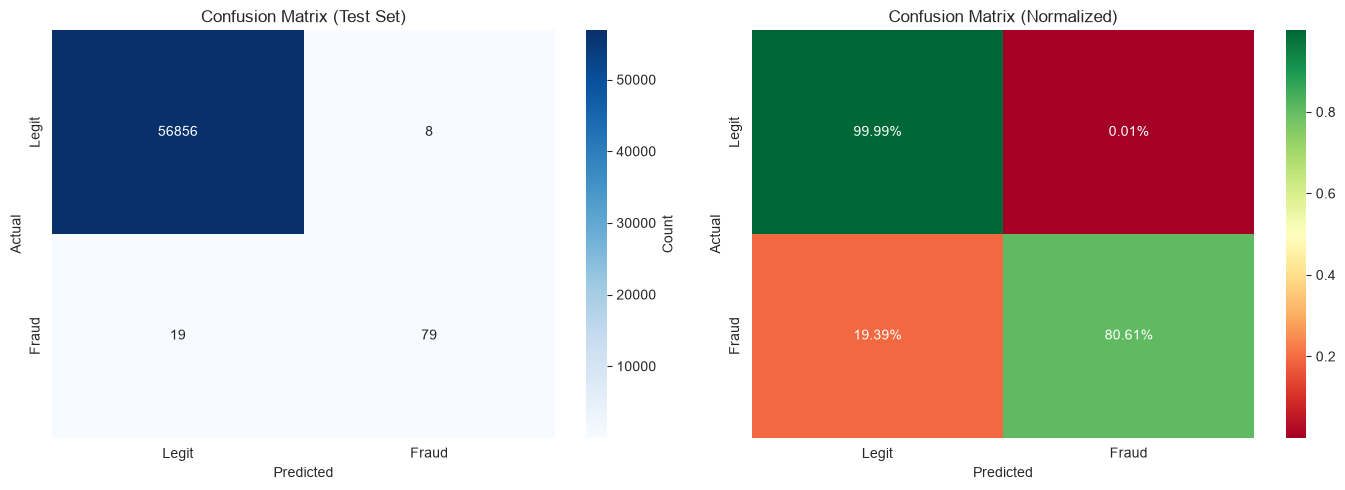

In [9]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Test Set)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn', ax=axes[1],
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

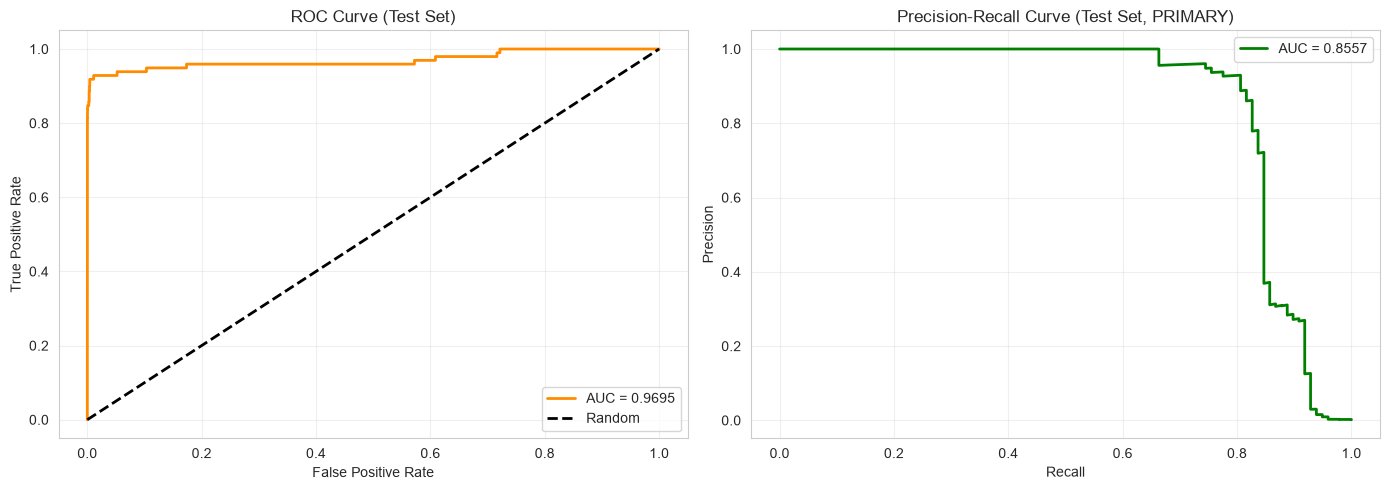

In [10]:
# ROC & PR curves
fpr_vals, tpr_vals, _ = roc_curve(y_test_final, y_test_pred_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_test_final, y_test_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr_vals, tpr_vals, color='darkorange', lw=2, label=f'AUC = {auc_roc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (Test Set)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(recall_vals, precision_vals, color='green', lw=2, label=f'AUC = {auc_pr:.4f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Test Set, PRIMARY)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Feature Importance

Top 10 Features (XGBoost Importance):
 1. V14: 0.629292
 2. V12: 0.052471
 3. V4: 0.044008
 4. Amount: 0.030411
 5. V13: 0.023727
 6. V27: 0.022146
 7. V21: 0.015471
 8. V18: 0.014027
 9. V20: 0.013954
10. V10: 0.013315


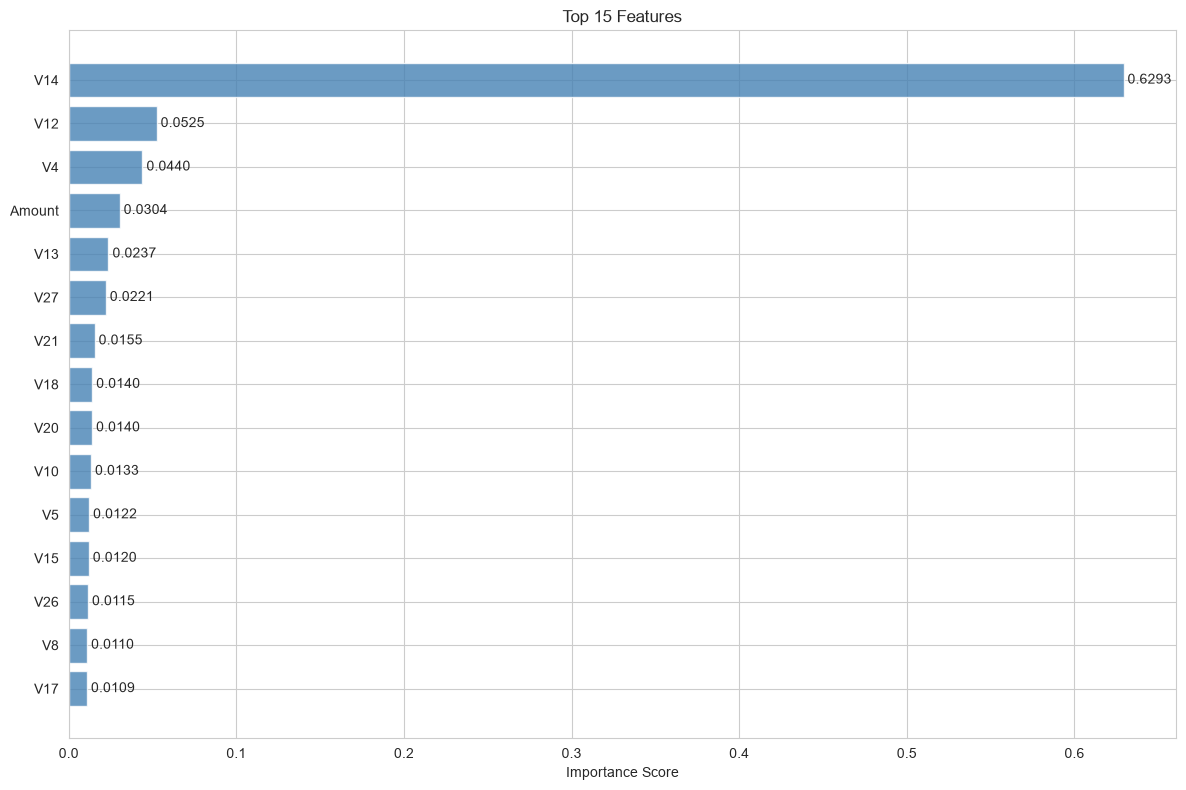

In [11]:
importance = model.feature_importances_
importance_dict = dict(zip(feature_names, importance))
sorted_features = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)

print('Top 10 Features (XGBoost Importance):')
for i, (name, score) in enumerate(sorted_features[:10], 1):
    print(f'{i:2d}. {name}: {score:.6f}')

# Plot
top_n = 15
top_features = sorted_features[:top_n]
names = [f[0] for f in top_features]
scores = [f[1] for f in top_features]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(names)), scores, color='steelblue', alpha=0.8)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel('Importance Score')
ax.set_title(f'Top {top_n} Features')
ax.invert_yaxis()

for bar, val in zip(bars, scores):
    ax.text(val, bar.get_y() + bar.get_height()/2, f' {val:.4f}', va='center')

plt.tight_layout()
plt.show()

## 10. Quantum-Ready Feature Selection

In [12]:
# Select top 8 features for quantum
top_k = 8
top_features_selected = [f[0] for f in sorted_features[:top_k]]
top_feature_indices = [feature_names.index(f) for f in top_features_selected]

print(f'Quantum-ready features (top {top_k}):')
cumsum = 0
for i, (name, score) in enumerate(sorted_features[:top_k], 1):
    cumsum += score
    print(f'{i}. {name}: {score:.4f} (cumsum: {cumsum:.4f})')

# Create quantum datasets
X_train_quantum = X_train_scaled[:, top_feature_indices]
X_val_quantum = X_val_scaled[:, top_feature_indices]
X_test_quantum = X_test_scaled[:, top_feature_indices]

print(f'\nDimensionality reduction: {X_train_scaled.shape[1]} → {X_train_quantum.shape[1]} features')
print(f'Cumulative importance (top 8): {cumsum:.2%}')

# Save quantum datasets (training + validation combined for Phase 2, test separate)
# Note: Phase 2 can use validation set for hyperparameter tuning if needed
X_combined_quantum = np.vstack([X_train_quantum, X_val_quantum])
y_combined = np.concatenate([y_train, y_val])

np.save('data/processed/X_train_quantum.npy', X_combined_quantum)
np.save('data/processed/X_test_quantum.npy', X_test_quantum)
np.save('data/processed/y_train_quantum.npy', y_combined)
np.save('data/processed/y_test_quantum.npy', y_test_final)
np.save('data/processed/quantum_features.npy', np.array(top_features_selected, dtype=object))

print(f'\nQuantum datasets saved:')
print(f'  X_train_quantum: {X_combined_quantum.shape} (train+val combined)')
print(f'  X_test_quantum: {X_test_quantum.shape} (final test, untouched)')
print(f'  y_train_quantum: {y_combined.shape}')
print(f'  y_test_quantum: {y_test_final.shape}')

Quantum-ready features (top 8):
1. V14: 0.6293 (cumsum: 0.6293)
2. V12: 0.0525 (cumsum: 0.6818)
3. V4: 0.0440 (cumsum: 0.7258)
4. Amount: 0.0304 (cumsum: 0.7562)
5. V13: 0.0237 (cumsum: 0.7799)
6. V27: 0.0221 (cumsum: 0.8021)
7. V21: 0.0155 (cumsum: 0.8175)
8. V18: 0.0140 (cumsum: 0.8316)

Dimensionality reduction: 30 → 8 features
Cumulative importance (top 8): 83.16%

Quantum datasets saved:
  X_train_quantum: (227845, 8) (train+val combined)
  X_test_quantum: (56962, 8) (final test, untouched)
  y_train_quantum: (227845,)
  y_test_quantum: (56962,)


## 11. Final Summary Report

In [13]:
print('\n' + '='*80)
print('PHASE 1 COMPLETE - CLASSICAL BASELINE ESTABLISHED')
print('='*80)

summary = f"""
DATASET:
  Source: D:\\datasets\\creditcard.csv (Real ULB Kaggle dataset)
  Total: {len(df):,} transactions
  Fraud: {int(class_counts[1]):,} ({df['Class'].mean():.4%})
  Imbalance: 1 fraud per {int(class_counts[0]/class_counts[1]):,} legitimate

SPLIT METHODOLOGY (NO DATA LEAKAGE):
  Training set:   {X_train.shape[0]:,} ({100*X_train.shape[0]/len(df):.1f}%)
                  {y_train.sum():,} fraud ({y_train.mean():.4%})
  Validation set: {X_val.shape[0]:,} ({100*X_val.shape[0]/len(df):.1f}%)
                  {y_val.sum():,} fraud ({y_val.mean():.4%})
  Test set:       {X_test_final.shape[0]:,} ({100*X_test_final.shape[0]/len(df):.1f}%)
                  {y_test_final.sum():,} fraud ({y_test_final.mean():.4%})

PREPROCESSING:
  Scaler: StandardScaler fitted on TRAINING set only
  Applied to: Validation and Test (using training parameters)
  Data leakage: ELIMINATED

HYPERPARAMETER TUNING:
  Method: GridSearchCV on training set
  Evaluation: 3-fold CV on training set
  Best max_depth: {best_params['max_depth']}
  Best learning_rate: {best_params['learning_rate']}
  Best CV F1: {grid_search.best_score_:.4f}

MODEL:
  Algorithm: XGBoost
  n_estimators: 100
  max_depth: {best_params['max_depth']}
  learning_rate: {best_params['learning_rate']}
  scale_pos_weight: {scale_pos_weight:.2f}
  Early stopping: monitored on validation set

THRESHOLD OPTIMIZATION:
  Optimization set: VALIDATION set only
  Optimal threshold: {optimal_threshold:.2f}
  Validation F1 at optimal: {threshold_df.loc[best_threshold_idx, 'f1']:.4f}

FINAL METRICS (TEST SET - UNTOUCHED UNTIL NOW):
  Accuracy:  {accuracy:.4f}
  Precision: {precision:.4f}
  Recall:    {recall:.4f}
  F1 Score:  {f1:.4f}
  AUC-ROC:   {auc_roc:.4f}
  PR-AUC:    {auc_pr:.4f} (PRIMARY METRIC for imbalanced data)

CONFUSION MATRIX (TEST SET):
  True Positives:  {tp} (fraud caught)
  True Negatives:  {tn} (legitimate cleared)
  False Positives: {fp} (false alarms)
  False Negatives: {fn} (missed fraud)
  False Positive Rate: {fpr:.4f}
  False Negative Rate: {fnr:.4f}

FEATURE IMPORTANCE:
  Dominant: {sorted_features[0][0]} ({sorted_features[0][1]:.4f})
  Top 3: {sorted_features[0][0]}, {sorted_features[1][0]}, {sorted_features[2][0]}

QUANTUM-READY DATASET:
  Features selected: 8 (from 30)
  Cumulative importance: {sum([s for _, s in sorted_features[:8]]):.2%}
  X_train: {X_combined_quantum.shape} (training + validation combined)
  X_test: {X_test_quantum.shape} (final test)
  
REPRODUCIBILITY:
  Model saved: data/processed/xgboost_model.joblib
  Scaler saved: data/processed/scaler.joblib
  Results JSON: data/processed/phase1_results.json
  Quantum datasets: data/processed/X_*_quantum.npy, y_*_quantum.npy
  Features: data/processed/quantum_features.npy
  
Ready for Phase 2: Quantum model development on 8-feature dataset
"""

print(summary)
print('='*80)
print('PHASE 1 COMPLETE — READY FOR PHASE 2')
print('='*80)


PHASE 1 COMPLETE - CLASSICAL BASELINE ESTABLISHED

DATASET:
  Source: D:\datasets\creditcard.csv (Real ULB Kaggle dataset)
  Total: 284,807 transactions
  Fraud: 492 (0.1727%)
  Imbalance: 1 fraud per 577 legitimate

SPLIT METHODOLOGY (NO DATA LEAKAGE):
  Training set:   170,883 (60.0%)
                  295 fraud (0.1726%)
  Validation set: 56,962 (20.0%)
                  99 fraud (0.1738%)
  Test set:       56,962 (20.0%)
                  98 fraud (0.1720%)

PREPROCESSING:
  Scaler: StandardScaler fitted on TRAINING set only
  Applied to: Validation and Test (using training parameters)
  Data leakage: ELIMINATED

HYPERPARAMETER TUNING:
  Method: GridSearchCV on training set
  Evaluation: 3-fold CV on training set
  Best max_depth: 7
  Best learning_rate: 0.1
  Best CV F1: 0.8572

MODEL:
  Algorithm: XGBoost
  n_estimators: 100
  max_depth: 7
  learning_rate: 0.1
  scale_pos_weight: 578.26
  Early stopping: monitored on validation set

THRESHOLD OPTIMIZATION:
  Optimization set: VA

In [14]:
# Save detailed results to JSON
import json

results_dict = {
    'dataset': {
        'total_transactions': len(df),
        'fraud_transactions': int(class_counts[1]),
        'fraud_percentage': float(df['Class'].mean()),
    },
    'split': {
        'training_samples': int(X_train.shape[0]),
        'validation_samples': int(X_val.shape[0]),
        'test_samples': int(X_test_final.shape[0]),
        'train_fraud_pct': float(y_train.mean()),
        'val_fraud_pct': float(y_val.mean()),
        'test_fraud_pct': float(y_test_final.mean()),
    },
    'model': {
        'algorithm': 'XGBoost',
        'best_max_depth': int(best_params['max_depth']),
        'best_learning_rate': float(best_params['learning_rate']),
        'scale_pos_weight': float(scale_pos_weight),
    },
    'threshold': {
        'optimal_value': float(optimal_threshold),
        'optimization_set': 'validation',
    },
    'metrics': {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'auc_roc': float(auc_roc),
        'pr_auc': float(auc_pr),
    },
    'confusion_matrix': {
        'true_positives': int(tp),
        'true_negatives': int(tn),
        'false_positives': int(fp),
        'false_negatives': int(fn),
        'false_positive_rate': float(fpr),
        'false_negative_rate': float(fnr),
    },
    'top_features': {f: float(s) for f, s in sorted_features[:10]},
    'quantum_features': top_features_selected,
}

with open('data/processed/phase1_results.json', 'w') as f:
    json.dump(results_dict, f, indent=2)

print('Results saved to phase1_results.json')

Results saved to phase1_results.json
